# Training, Validation and Test Data

When building a machine learning model, the complete dataset is usually divided into **Training**, **Validation**, and **Test** sets. Each dataset has a different purpose during the model development process.

The model is **trained** using the training data, **tuned** using the validation data, and finally **evaluated** using the test data.

---

# Training Data

The **Training Dataset** is the portion of data used to teach the machine learning model. During this phase, the model learns patterns, relationships, and trends from the data.

The training dataset is usually the **largest portion** of the dataset because the model requires sufficient data to learn effectively.

For example:

- Training Data = **80%**
- Test Data = **20%**

The exact split may vary depending on the problem and dataset size.

---

# Validation Data

A **Validation Dataset** is a portion of the training data that is **held back from training**. It is used to evaluate the model during development and to **tune hyperparameters**.

Hyperparameters are values that are chosen before training begins, such as:

- Value of **k** in kNN
- Learning rate
- Number of trees
- Maximum tree depth

The validation data helps us compare different models or different hyperparameter values and choose the one that performs best.

> **The validation dataset is used for model selection and hyperparameter tuning.**

---

# Test Data

The **Test Dataset** is completely unseen data that is **never used during training or validation**.

Once the best model has been selected using the validation dataset, it is evaluated one final time on the test dataset. This gives an unbiased estimate of how well the model will perform on new, unseen data.

> **The test dataset is used only once, after the final model has been selected.**

---

# Workflow

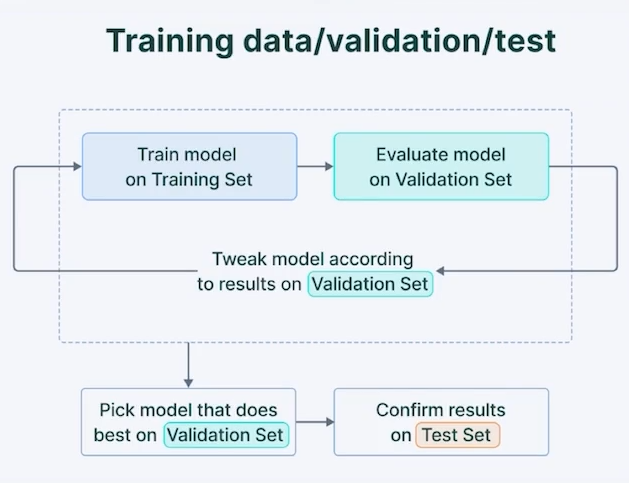

The model development process follows these steps:

1. Train the model using the **Training Dataset**.
2. Evaluate the model using the **Validation Dataset**.
3. Tune the hyperparameters based on the validation results.
4. Repeat the process until the best-performing model is obtained.
5. Finally, evaluate the selected model on the **Test Dataset**.

The workflow can be summarized as:

```text
Training Data
      │
      ▼
Train the Model
      │
      ▼
Validation Data
      │
      ▼
Evaluate & Tune Hyperparameters
      │
      ▼
Select Best Model
      │
      ▼
Test Data
      │
      ▼
Final Performance
```

---

# Cross Validation

Sometimes the available dataset is small, and setting aside a separate validation dataset reduces the amount of data available for training. To solve this problem, **Cross Validation** is used.

Cross Validation allows the model to be trained and validated multiple times using different portions of the dataset. This provides a more reliable estimate of the model's performance.

---

# K-Fold Cross Validation

The most common type of cross validation is **K-Fold Cross Validation**.

In this technique, the training dataset is divided into **K equal-sized folds (parts)**.

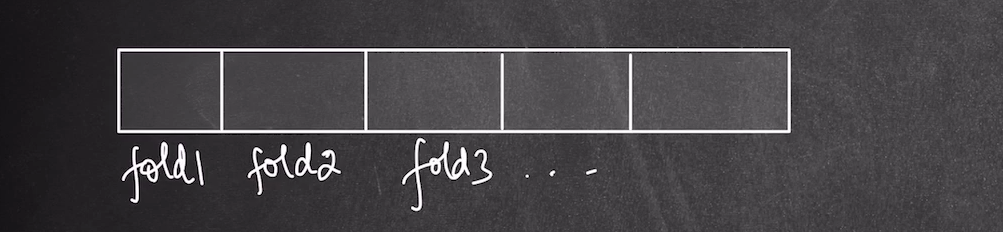

For example, if **K = 5**, the training data is divided into **5 equal folds**.

During each iteration:

- One fold is used as the **Validation Dataset**.
- The remaining **K − 1 folds** are used for **Training**.

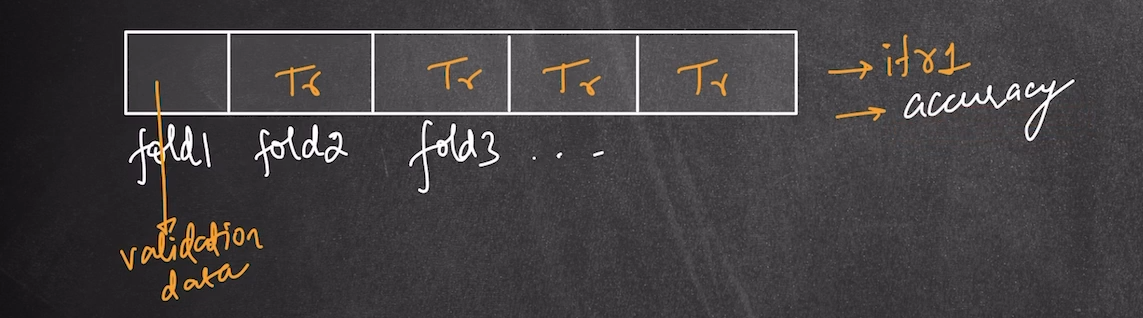

This process continues until every fold has been used once as the validation dataset.

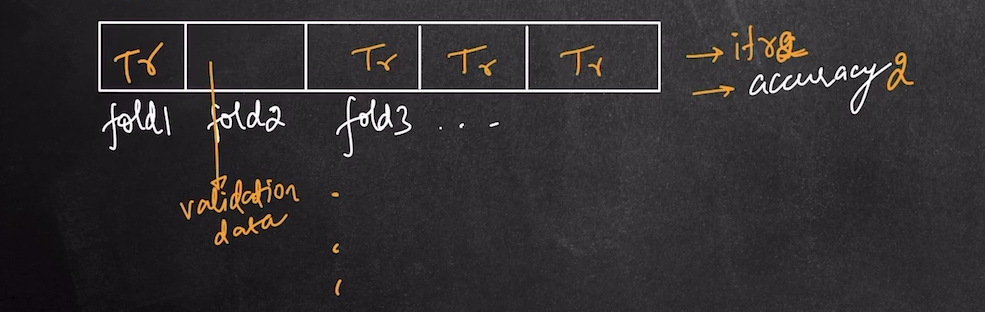

For **K = 5**:

| Iteration | Training Folds | Validation Fold |
|-----------|----------------|-----------------|
| 1 | Fold 2, 3, 4, 5 | Fold 1 |
| 2 | Fold 1, 3, 4, 5 | Fold 2 |
| 3 | Fold 1, 2, 4, 5 | Fold 3 |
| 4 | Fold 1, 2, 3, 5 | Fold 4 |
| 5 | Fold 1, 2, 3, 4 | Fold 5 |

After each iteration, the model's validation score (such as accuracy) is recorded.

Finally, the **average of all validation scores** is calculated.

> **Average Validation Score = Final Cross Validation Score**

The model with the best average score is selected.

---

# Why use Cross Validation?

Cross Validation provides a more reliable estimate of model performance because every data point gets a chance to be part of the validation dataset.

Compared to using a single validation split, it reduces the chances of obtaining misleading results due to a fortunate or unfortunate train-validation split.

---

# Advantages of Cross Validation

- Makes better use of the available data.
- Produces a more reliable estimate of model performance.
- Reduces the effect of random train-validation splits.
- Helps select the best model and hyperparameters.
- Commonly used when the dataset is small.

---

# Important Points to Remember

- **Training Data** is used to train the model.
- **Validation Data** is used to tune hyperparameters and select the best model.
- **Test Data** is used only for the final evaluation.
- The test dataset should never be used during training or hyperparameter tuning.
- **K-Fold Cross Validation** divides the training data into **K folds**.
- Each fold is used once as the validation dataset.
- The **average validation score** from all folds is considered the final performance estimate.

---
---
# Hyperparameter Tuning using GridSearchCV

**GridSearchCV** is a technique used to find the **best combination of hyperparameters** for a machine learning model using **Cross Validation**.

Instead of manually testing different values, GridSearchCV automatically trains and evaluates the model for every combination of hyperparameters and selects the one with the best performance.

---

# Why do we need GridSearchCV?

Many machine learning algorithms have **hyperparameters** that are not learned from the data.

For example, in **kNN**, the value of **k (number of neighbors)** is a hyperparameter.

Different values of **k** may produce different model performances. Rather than choosing a value randomly, GridSearchCV tests multiple values and finds the best one.

In this example, the following values are tested:

```python
n_neighbors = [3, 5, 7, 9]
```

---

# What is Cross Validation?

GridSearchCV uses **K-Fold Cross Validation** to evaluate every hyperparameter.

For **cv = 5**:

- The training data is divided into **5 equal folds**.
- The model is trained on **4 folds**.
- The remaining **1 fold** is used for validation.
- This process repeats **5 times**, so every fold becomes the validation set once.
- The average validation score is calculated.

This average score is used to compare different hyperparameter values.

---

# Understanding the Code

### Step 1: Create the Model

First, create a kNN classifier.

```python
classifier = KNeighborsClassifier()
```

---

### Step 2: Define the Hyperparameter Grid

Specify the values of the hyperparameter that should be tested.

```python
param_grid = {
    "n_neighbors": [3, 5, 7, 9]
}
```

GridSearchCV will train four different models using:

- k = 3
- k = 5
- k = 7
- k = 9

---

### Step 3: Create GridSearchCV

```python
classifierCV = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    cv=5,
    scoring="recall"
)
```

Here,

- **estimator** → Machine learning model to train.
- **param_grid** → Hyperparameter values to test.
- **cv=5** → Perform 5-Fold Cross Validation.
- **scoring="recall"** → Select the model with the highest Recall Score.

---

### Step 4: Train the Model

```python
classifierCV.fit(X_train_scaled, y_train)
```

GridSearchCV automatically:

- Trains the model.
- Performs Cross Validation.
- Calculates the validation score.
- Finds the best hyperparameter.

---

### Step 5: Make Predictions

```python
y_pred = classifierCV.predict(X_test_scaled)
```

The model with the **best hyperparameter** is used to make predictions on the test dataset.

---

### Step 6: Evaluate the Model

The trained model is evaluated using different performance metrics.

- **Accuracy** measures the overall correctness of the model.
- **Precision** measures how many predicted positive samples are actually positive.
- **Recall** measures how many actual positive samples are correctly identified.

---

### Step 7: View Cross Validation Results

```python
results = pd.DataFrame(classifierCV.cv_results_)
```

The `cv_results_` attribute stores the performance of every hyperparameter tested during Cross Validation.

Displaying:

```python
results[["param_n_neighbors", "mean_test_score"]]
```

shows:

- The value of **k** tested.
- Its average Cross Validation score.

Example:

| k | Mean Test Score |
|---|-----------------|
| 3 | 0.864 |
| 5 | 0.858 |
| 7 | 0.872 |
| 9 | 0.857 |

---

### Step 8: Find the Best Hyperparameter

```python
classifierCV.best_params_
```

This returns the hyperparameter that achieved the highest Cross Validation score.

Example:

```python
{'n_neighbors': 7}
```

This means **k = 7** produced the best performance and is automatically selected by GridSearchCV.

---

# Summary

- **GridSearchCV** automatically searches for the best hyperparameter values.
- It evaluates each combination using **K-Fold Cross Validation**.
- The average validation score is calculated for every hyperparameter.
- The hyperparameter with the highest score is selected.
- The selected model is then used for prediction on the test dataset.
- This approach is more reliable than manually choosing hyperparameter values.

In [5]:
# Cross Validation for Hyperparameter Tuning using GridSearchCV

import pandas as pd

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

#read data
heart_df=pd.read_csv("heart.csv")
X = heart_df.drop("target", axis=1)
y = heart_df["target"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Create the KNN classifier
classifier = KNeighborsClassifier()

# Hyperparameter values to test --- a dictionary or a list of dictionaries
param_grid = {
    "n_neighbors": [3, 5, 7, 9]
}

# Apply GridSearchCV with 5-Fold Cross Validation
classifierCV = GridSearchCV(
    classifier, # model on which we apply -- classifierCV = KNeighborsClassifier()
    param_grid,
    cv=5,                # no of folds
    scoring="recall"     # can also be tested on accuracy... etc.
)

# Train the model
classifierCV.fit(X_train_scaled, y_train)

# Make predictions
y_pred = classifierCV.predict(X_test_scaled)

# Evaluation Metrics
print("Recall Score    :", recall_score(y_test, y_pred))
print("Accuracy Score  :", accuracy_score(y_test, y_pred))
print("Precision Score :", precision_score(y_test, y_pred))

# Display Cross Validation Results
results = pd.DataFrame(classifierCV.cv_results_)
print("\nCross Validation Results:")
print(results[["param_n_neighbors", "mean_test_score"]])

# Best Hyperparameter
print("\nBest Hyperparameter:")
print(classifierCV.best_params_)

Recall Score    : 0.90625
Accuracy Score  : 0.9180327868852459
Precision Score : 0.9354838709677419

Cross Validation Results:
   param_n_neighbors  mean_test_score
0                  3         0.864387
1                  5         0.857550
2                  7         0.871795
3                  9         0.856980

Best Hyperparameter:
{'n_neighbors': 7}


---
# How GridSearchCV Works

The easiest way to understand **GridSearchCV** is to imagine that **you are the computer**.

Suppose we define the following hyperparameter values:

```python
param_grid = {
    "n_neighbors": [3, 5, 7, 9]
}
```

The computer thinks:

> *"I don't know which value of **k** is the best, so I'll try every value one by one."*

---

# Step 1: Try **k = 3**

Since we specified:

```python
cv = 5
```

GridSearchCV performs **5-Fold Cross Validation**.

The training dataset is divided into **5 equal folds**.

```text
Dataset
│
├── Fold 1
├── Fold 2
├── Fold 3
├── Fold 4
└── Fold 5
```

---

### Iteration 1

```text
Validation → Fold 1

Training → Fold 2 + Fold 3 + Fold 4 + Fold 5
```

Suppose the Recall Score is:

```text
0.85
```

---

### Iteration 2

```text
Validation → Fold 2

Training → Fold 1 + Fold 3 + Fold 4 + Fold 5
```

Suppose the Recall Score is:

```text
0.88
```

---

### Iteration 3

```text
Validation → Fold 3

Training → Fold 1 + Fold 2 + Fold 4 + Fold 5
```

Suppose the Recall Score is:

```text
0.86
```

---

### Iteration 4

```text
Validation → Fold 4

Training → Fold 1 + Fold 2 + Fold 3 + Fold 5
```

Suppose the Recall Score is:

```text
0.84
```

---

### Iteration 5

```text
Validation → Fold 5

Training → Fold 1 + Fold 2 + Fold 3 + Fold 4
```

Suppose the Recall Score is:

```text
0.89
```

---

Now GridSearchCV calculates the **average Recall Score**.

$$
\frac{0.85 + 0.88 + 0.86 + 0.84 + 0.89}{5} = 0.864
$$

It stores the result as:

```text
k = 3

Average Recall = 0.864
```

---

# Step 2: Try **k = 5**

Again, GridSearchCV performs **5-Fold Cross Validation**.

```text
Fold 1 → Validation

Fold 2 → Validation

Fold 3 → Validation

Fold 4 → Validation

Fold 5 → Validation
```

After calculating the average:

```text
Average Recall = 0.857
```

It stores:

```text
k = 5

Average Recall = 0.857
```

---

# Step 3: Try **k = 7**

Again, GridSearchCV performs **5-Fold Cross Validation**.

After calculating the average:

```text
Average Recall = 0.871
```

It stores:

```text
k = 7

Average Recall = 0.871
```

---

# Step 4: Try **k = 9**

Again, GridSearchCV performs **5-Fold Cross Validation**.

After calculating the average:

```text
Average Recall = 0.856
```

It stores:

```text
k = 9

Average Recall = 0.856
```

---

# Comparing the Results

After testing every value of **k**, GridSearchCV creates a table similar to this:

| k | Average Recall |
|---|---------------:|
| 3 | 0.864 |
| 5 | 0.857 |
| 7 | **0.871 ✅** |
| 9 | 0.856 |

Now it simply asks:

> **Which value of k has the highest average Recall Score?**

The answer is:

```text
k = 7
```

Therefore,

```python
classifierCV.best_params_
```

returns

```python
{'n_neighbors': 7}
```

---

# What Happens Next?

After finding the best value (**k = 7**), GridSearchCV automatically creates the **final model** using that hyperparameter.

So when we write:

```python
y_pred = classifierCV.predict(X_test_scaled)
```

GridSearchCV is internally doing something similar to this:

```python
best_model = KNeighborsClassifier(n_neighbors=7)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
```

We do **not** need to write this code ourselves because GridSearchCV automatically trains the final model using the best hyperparameter.

---

# Why Do We Use the Test Dataset?

During GridSearchCV, the model has already used the **training dataset** multiple times through Cross Validation.

If we evaluated the model on the training data again, the performance would be **overly optimistic** because the model has already seen that data.

Instead, we evaluate the final model using the **Test Dataset**, which has **never been used** during training or hyperparameter tuning.

This gives a realistic estimate of how well the model will perform on completely unseen data.

---

# Complete Workflow

```text
Training Data
      │
      ▼
Try k = 3
5-Fold Cross Validation
Average Recall = 0.864
      │
      ▼
Try k = 5
5-Fold Cross Validation
Average Recall = 0.857
      │
      ▼
Try k = 7
5-Fold Cross Validation
Average Recall = 0.871 ✅
      │
      ▼
Try k = 9
5-Fold Cross Validation
Average Recall = 0.856
      │
      ▼
Choose Best k = 7
      │
      ▼
Train Final Model with k = 7
      │
      ▼
Predict on Test Data
      │
      ▼
Calculate Accuracy, Precision and Recall
```

---

# Summary

GridSearchCV automates the entire hyperparameter tuning process. It tests every hyperparameter combination, evaluates each one using **K-Fold Cross Validation**, compares their average validation scores, selects the best-performing hyperparameter, retrains the model using that best value, and finally uses the trained model to make predictions on the unseen test dataset.


# Pipeline

In [8]:
# Pipeline
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42

)

# we pass the steps we want to perform in the pipeline . first scaling and then the model
pipeline = Pipeline([
('scaler', StandardScaler()),
('knn', KNeighborsClassifier())
])

param_grid = {"knn__n_neighbors": [3, 5, 7, 9]}

# now we pass the pipeline (scaling+model) in the GridSearchCV. ealier we passed only model as we did scaling manually.
classifierCV = GridSearchCV(
pipeline,
param_grid,
cv=5,
scoring="recall"
)

#train
classifierCV.fit(X_train, y_train)
#predict
y_pred = classifierCV.predict(X_test)

print("recall score: ", recall_score(y_test, y_pred))
print("accuracy score: ", accuracy_score(y_test, y_pred) )
print("precision score: ", precision_score(y_test, y_pred))

print(classifierCV.best_params_)

recall score:  0.90625
accuracy score:  0.9180327868852459
precision score:  0.9354838709677419
{'knn__n_neighbors': 7}


# Purpose of Important Machine Learning Tools

As machine learning projects become larger, manually handling preprocessing, model selection, and evaluation becomes difficult. Libraries such as **Scikit-learn** provide utilities like **Train-Test Split**, **Cross Validation**, **GridSearchCV**, and **Pipeline** to automate these tasks and build more reliable models.

---

# 1. Train-Test Split

### Purpose

The purpose of **Train-Test Split** is to divide the dataset into **training data** and **testing data**.

The training data is used to train the model, while the testing data is kept completely unseen and is used to evaluate the final performance of the trained model.

Without a train-test split, we cannot determine how well the model performs on new, unseen data.

---

# 2. Validation Set

### Purpose

The purpose of the **Validation Set** is to evaluate the model during training and help choose the best model or the best hyperparameters.

Instead of repeatedly testing different models on the test dataset, we use the validation dataset for model selection and hyperparameter tuning.

This keeps the test dataset completely unseen until the final evaluation.

---

# 3. Cross Validation

### Purpose

The purpose of **Cross Validation** is to produce a **more reliable estimate** of model performance.

Instead of evaluating the model using a single validation split, Cross Validation trains and validates the model multiple times using different portions of the dataset.

This reduces the effect of random train-validation splits and makes better use of the available data.

---

# 4. K-Fold Cross Validation

### Purpose

The purpose of **K-Fold Cross Validation** is to ensure that **every data sample gets a chance to be used as validation data**.

The training dataset is divided into **K equal folds**. During each iteration, one fold acts as the validation set while the remaining folds are used for training.

The final performance is calculated by averaging the scores from all iterations.

This provides a more stable and trustworthy estimate of model performance.

---

# 5. GridSearchCV

### Purpose

The purpose of **GridSearchCV** is to **automatically find the best hyperparameter values** for a machine learning model.

Instead of manually testing different hyperparameters, GridSearchCV tries every possible combination, evaluates each one using **Cross Validation**, and selects the combination with the highest performance score.

For example, in kNN it automatically determines the best value of **k**.

GridSearchCV also retrains the final model using the best hyperparameters, so no additional training is required.

> **Purpose:** Automatically perform hyperparameter tuning and select the best model.

---

# 6. Pipeline

### Purpose

The purpose of a **Pipeline** is to combine all preprocessing steps and the machine learning model into **one automated workflow**.

Instead of manually scaling data, training the model, and making predictions separately, the Pipeline performs every step in the correct order automatically.

Pipelines also prevent **Data Leakage** because preprocessing operations are fitted only on the training data and then applied to the validation or test data.

> **Purpose:** Automate preprocessing and model training while preventing data leakage.

---

# 7. StandardScaler

### Purpose

The purpose of **StandardScaler** is to standardize numerical features so that they have a similar scale.

It transforms every feature to have:

- Mean = 0
- Standard Deviation = 1

This prevents features with larger numerical values from dominating distance calculations.

StandardScaler is especially important for distance-based algorithms such as **kNN**.

---

# 8. Hyperparameters

### Purpose

Hyperparameters are values that are chosen **before training begins**.

They control how the machine learning algorithm learns from the data but are **not learned automatically** by the model.

Examples include:

- Number of neighbors (**k**) in kNN
- Learning rate
- Maximum tree depth
- Number of decision trees

The purpose of hyperparameter tuning is to find the values that produce the best model performance.

---

# 9. Data Leakage

### Purpose

Data Leakage is **not a tool**, but an important concept in machine learning.

It occurs when information from the validation or test dataset accidentally becomes available during training.

This results in overly optimistic evaluation scores because the model has indirectly seen the unseen data.

Pipelines are commonly used to prevent data leakage.

---

# Summary

| Tool / Concept | Purpose |
|----------------|---------|
| **Train-Test Split** | Split data into training and testing datasets. |
| **Validation Set** | Tune hyperparameters and select the best model. |
| **Cross Validation** | Obtain a more reliable estimate of model performance. |
| **K-Fold Cross Validation** | Use every sample as validation data once and average the results. |
| **GridSearchCV** | Automatically find the best hyperparameters using Cross Validation. |
| **Pipeline** | Automate preprocessing and model training while preventing data leakage. |
| **StandardScaler** | Scale features to a common range for better model performance. |
| **Hyperparameters** | Control the behavior of the learning algorithm before training. |
| **Data Leakage** | Prevent the model from learning information from unseen data. |